In [23]:
import numpy as np

from graphviz import Digraph
import networkx as nx
import networkx.algorithms as nxa
import re

import DeBruijnDNA
import AcyclicGraphDNA

import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler

from collections import defaultdict

import sys
sys.path.append("../HADOFv2")

import HADOFrun

import dill as pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [12]:
def solve_dwave(Q):
    """
    Q = np.array([[-1, 1, 0], [1, -1, -2], [0, -2, -1]])
    solve_dwave(Q)
    """
    q = {}
    size = len(Q)
    for i in range(size):
        for j in range(size):
            q[(i,j)] = Q[i][j]
            
    sampler = SimulatedAnnealingSampler()
    response = sampler.sample_qubo(q, num_reads=5000, anneal_time=20)

    # response = sampler.sample_qubo(q, num_reads = 5000, beta_range = [1,200], beta_schedule_type = 'linear', num_sweeps=50)

    result = []
    samples = []
    energies = []
    for sample, energy in response.data(['sample', 'energy']): 
        result.append(sample)
        result.append(energy)
    #     samples.append(sample)
    #     energies.append(energy)
    # result.append(samples[np.argmin(energies)])
    # result.append(energies[np.argmin(energies)])

    result.append(response.info) # view timings
    
    return result

Loading the String Graph

In [13]:
filename = "ERR13577262_raw_string.gfa"
segments, links, containments = AcyclicGraphDNA.load_file(filename)
segments = [l.replace(":", "/", 1) for l in segments]
links = [l.replace(":", "/", 2) for l in links]


initial_graph, adjacency_matrix, nodes_indices, nodes_labels, links_edges = AcyclicGraphDNA.get_initial_graph(segments, links)
strand_graph = AcyclicGraphDNA.get_strand_graph(initial_graph)

print('links quantity: ', len(links_edges))

segments: 524, links: 4642, containments: 0, lines: 5166

nodes quantity: 1048
links quantity:  4632


strand_adjacency_matrix size: 524


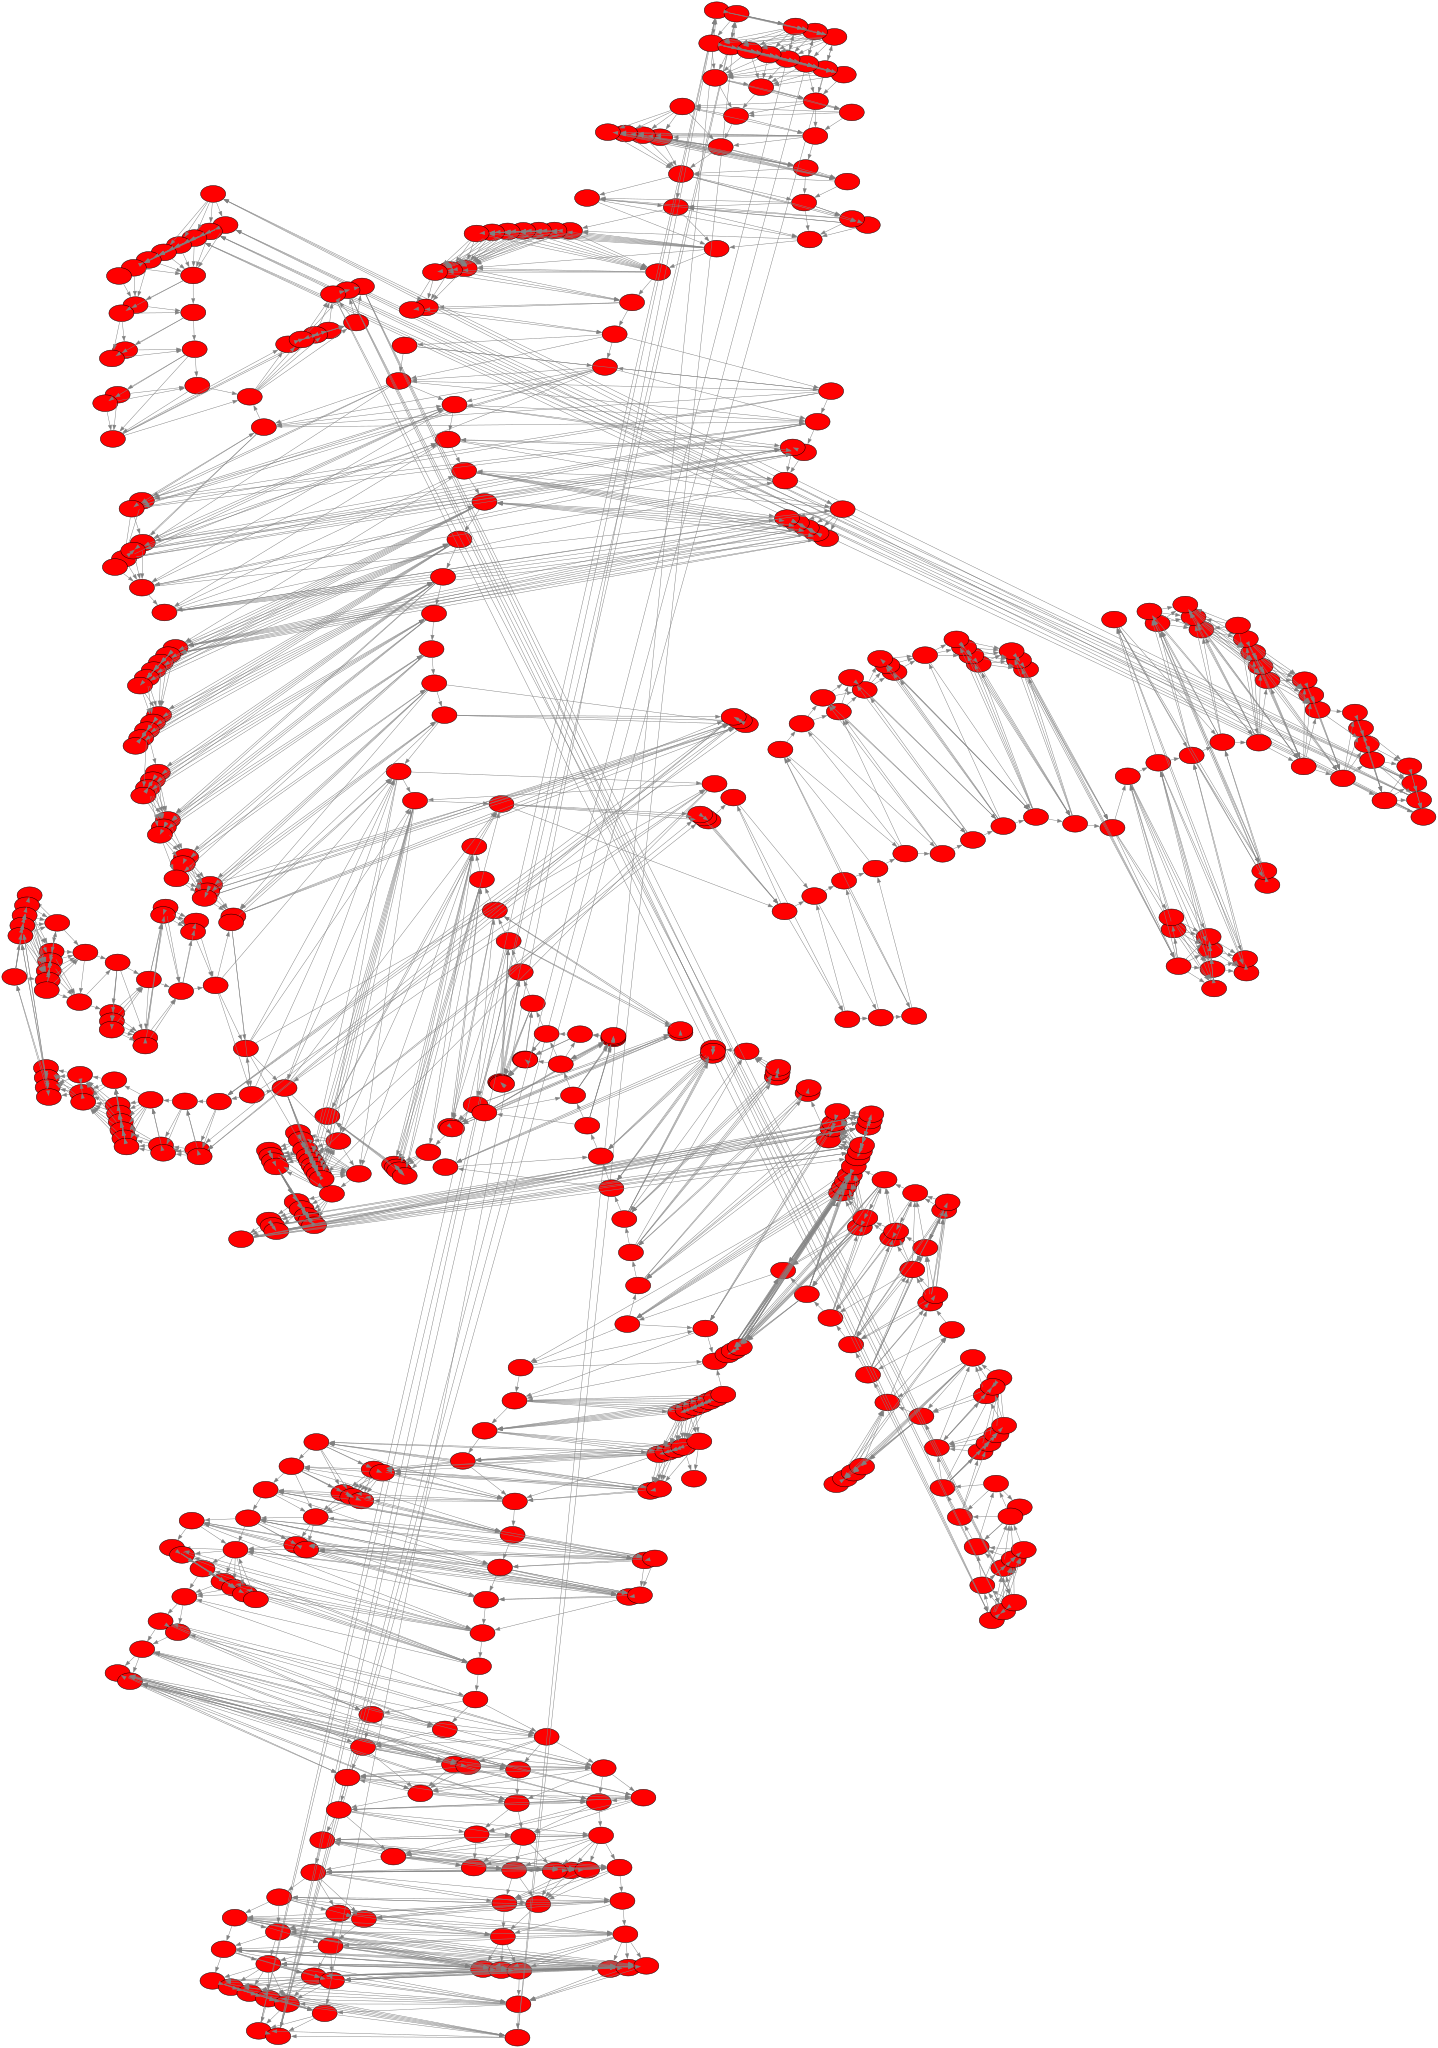

In [14]:
strand_graph_adjacency_matrix = nx.to_numpy_matrix(strand_graph)
print('strand_adjacency_matrix size:', len(strand_graph_adjacency_matrix))

edges = np.argwhere(strand_graph_adjacency_matrix==1).tolist()
nodes = list(strand_graph.nodes)
g = AcyclicGraphDNA.draw_graph(nodes, solve_edges=[], edges=edges)
g.engine = 'twopi'
# g.engine = "fdp"
g

In [15]:
strand_graph_undirected = AcyclicGraphDNA.complement_to_undirected_graph(strand_graph)
adjacency_matrix = nx.to_numpy_matrix(strand_graph_undirected)
part_map, _ , _ = AcyclicGraphDNA.part_graph(cluster_number=1, adjacency_matrix=adjacency_matrix)

graphs = []
node_labels = list(strand_graph_undirected.nodes)
node_lengths = [len(segments[i//2])-len(node_labels[i])-3 for i in range(len(node_labels))]
for part, nodes_indices in part_map.items():
    labels = [node_labels[i] for i in nodes_indices]
    graphs.append(strand_graph.subgraph(labels))

Use the next 3 cells for solving using SA

In [ ]:
solve_edges=[]
split_solutions = []
for pg in graphs:
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()

    Q = AcyclicGraphDNA.to_qubo(adjacency_matrix, A=2)
    target_energy = -2.0*len(adjacency_matrix)+2
    solution = solve_dwave(Q)
    split_solutions.append(solution)

qubo_dict = defaultdict(int)
for i in range(2313):
    for j in range(i, 2313):
        if i==j:
            qubo_dict[(i,)] = Q[i][j]
        else:
            qubo_dict[(i, j)] = Q[i][j]

solutions = [solution[i] for i in range(len(solution)) if i%2==0]

: 

: 

In [ ]:
with open("results-SA-test.pkl", "wb") as f:
    pickle.dump([solutions[0], qubo_dict, solutions[1:]], f)

In [ ]:
scores = [solution[i] for i in range(1, 10000, 2)]
print('min score:', min(scores))
print('avg score:', sum(scores)/len(scores))

Use the next 3 cells for solving using HADOF

Problem device: \
"CPU" runs an ideal simulation of HADOF QAOA \
"fake_backend" runs a simulation of ibm_torino mimicking the device noise \
"real_backend" can be configured with an api code to execute on ibm QPUs

In [ ]:
HADOFrun.hadof_optimiser = "QAOAt"
HADOFrun.num_qubit = 3
HADOFrun.step_layers = 15
HADOFrun.steps = 5
HADOFrun.problem_device = "CPU"

solve_edges=[]
split_solutions = []
for pg in graphs:
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()

    Q = AcyclicGraphDNA.to_qubo(adjacency_matrix, A=2)
    sols = HADOFrun.main(Q)

    # solution = solve_dwave(Q)
    split_solutions.append(sols[2])
    solve_edges_idices=[]
    for i in range(len(Q)):
        if sols[0][i]==1:
            solve_edges_idices.append(edges_indices[i])

    node_labels = list(pg.nodes)
    solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
    solve_edges+=solve_edges_part

Step 1/15, Model: 1
Step 1/15, Model: 2
Step 1/15, Model: 3
Step 1/15, Model: 4
Step 1/15, Model: 5
Step 1/15, Model: 6
Step 1/15, Model: 7
Step 1/15, Model: 8
Step 1/15, Model: 9
Step 1/15, Model: 10
Step 1/15, Model: 11
Step 1/15, Model: 12
Step 1/15, Model: 13
Step 1/15, Model: 14
Step 1/15, Model: 15
Step 1/15, Model: 16
Step 1/15, Model: 17
Step 1/15, Model: 18
Step 1/15, Model: 19
Step 1/15, Model: 20
Step 1/15, Model: 21
Step 1/15, Model: 22
Step 1/15, Model: 23
Step 1/15, Model: 24
Step 1/15, Model: 25
Step 1/15, Model: 26
Step 1/15, Model: 27
Step 1/15, Model: 28
Step 1/15, Model: 29
Step 1/15, Model: 30
Step 1/15, Model: 31
Step 1/15, Model: 32
Step 1/15, Model: 33
Step 1/15, Model: 34
Step 1/15, Model: 35
Step 1/15, Model: 36
Step 1/15, Model: 37
Step 1/15, Model: 38
Step 1/15, Model: 39
Step 1/15, Model: 40
Step 1/15, Model: 41
Step 1/15, Model: 42
Step 1/15, Model: 43
Step 1/15, Model: 44
Step 1/15, Model: 45
Step 1/15, Model: 46
Step 1/15, Model: 47
Step 1/15, Model: 48
S

In [ ]:
with open("results-ideal-HADOF-test.pkl", "wb") as f:
    pickle.dump(sols, f)

In [8]:
scores = []
for i in range(5000):
    var1 = np.array(sols[2][i][:len(Q)])
    var2 = np.array(Q)

    scores.append(var1 @ var2 @ var1)
print('min score:', min(scores))
print('avg score:', sum(scores)/len(scores))

min score: -998.0
avg score: -997.372


To load pre-existing solutions

In [6]:
import dill as pickle
with open("results-real-device.pkl", "rb") as f:
    sols = pickle.load(f)

The next two cells are for visualisation of the solution. \
sol_no can be modified to view a particular sample solution

In [ ]:
sol_no = 0
solve_edges=[]
for num, pg in enumerate(graphs):
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()
    spins, energy = [split_solutions[num][sol_no][i] for i in split_solutions[num][sol_no].keys()], split_solutions[num][sol_no+1]

    solve_edges_idices=[]
    for i in range(len(spins)):
        if spins[i]==1:
            solve_edges_idices.append(edges_indices[i])

    node_labels = list(pg.nodes)
    solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
    solve_edges+=solve_edges_part

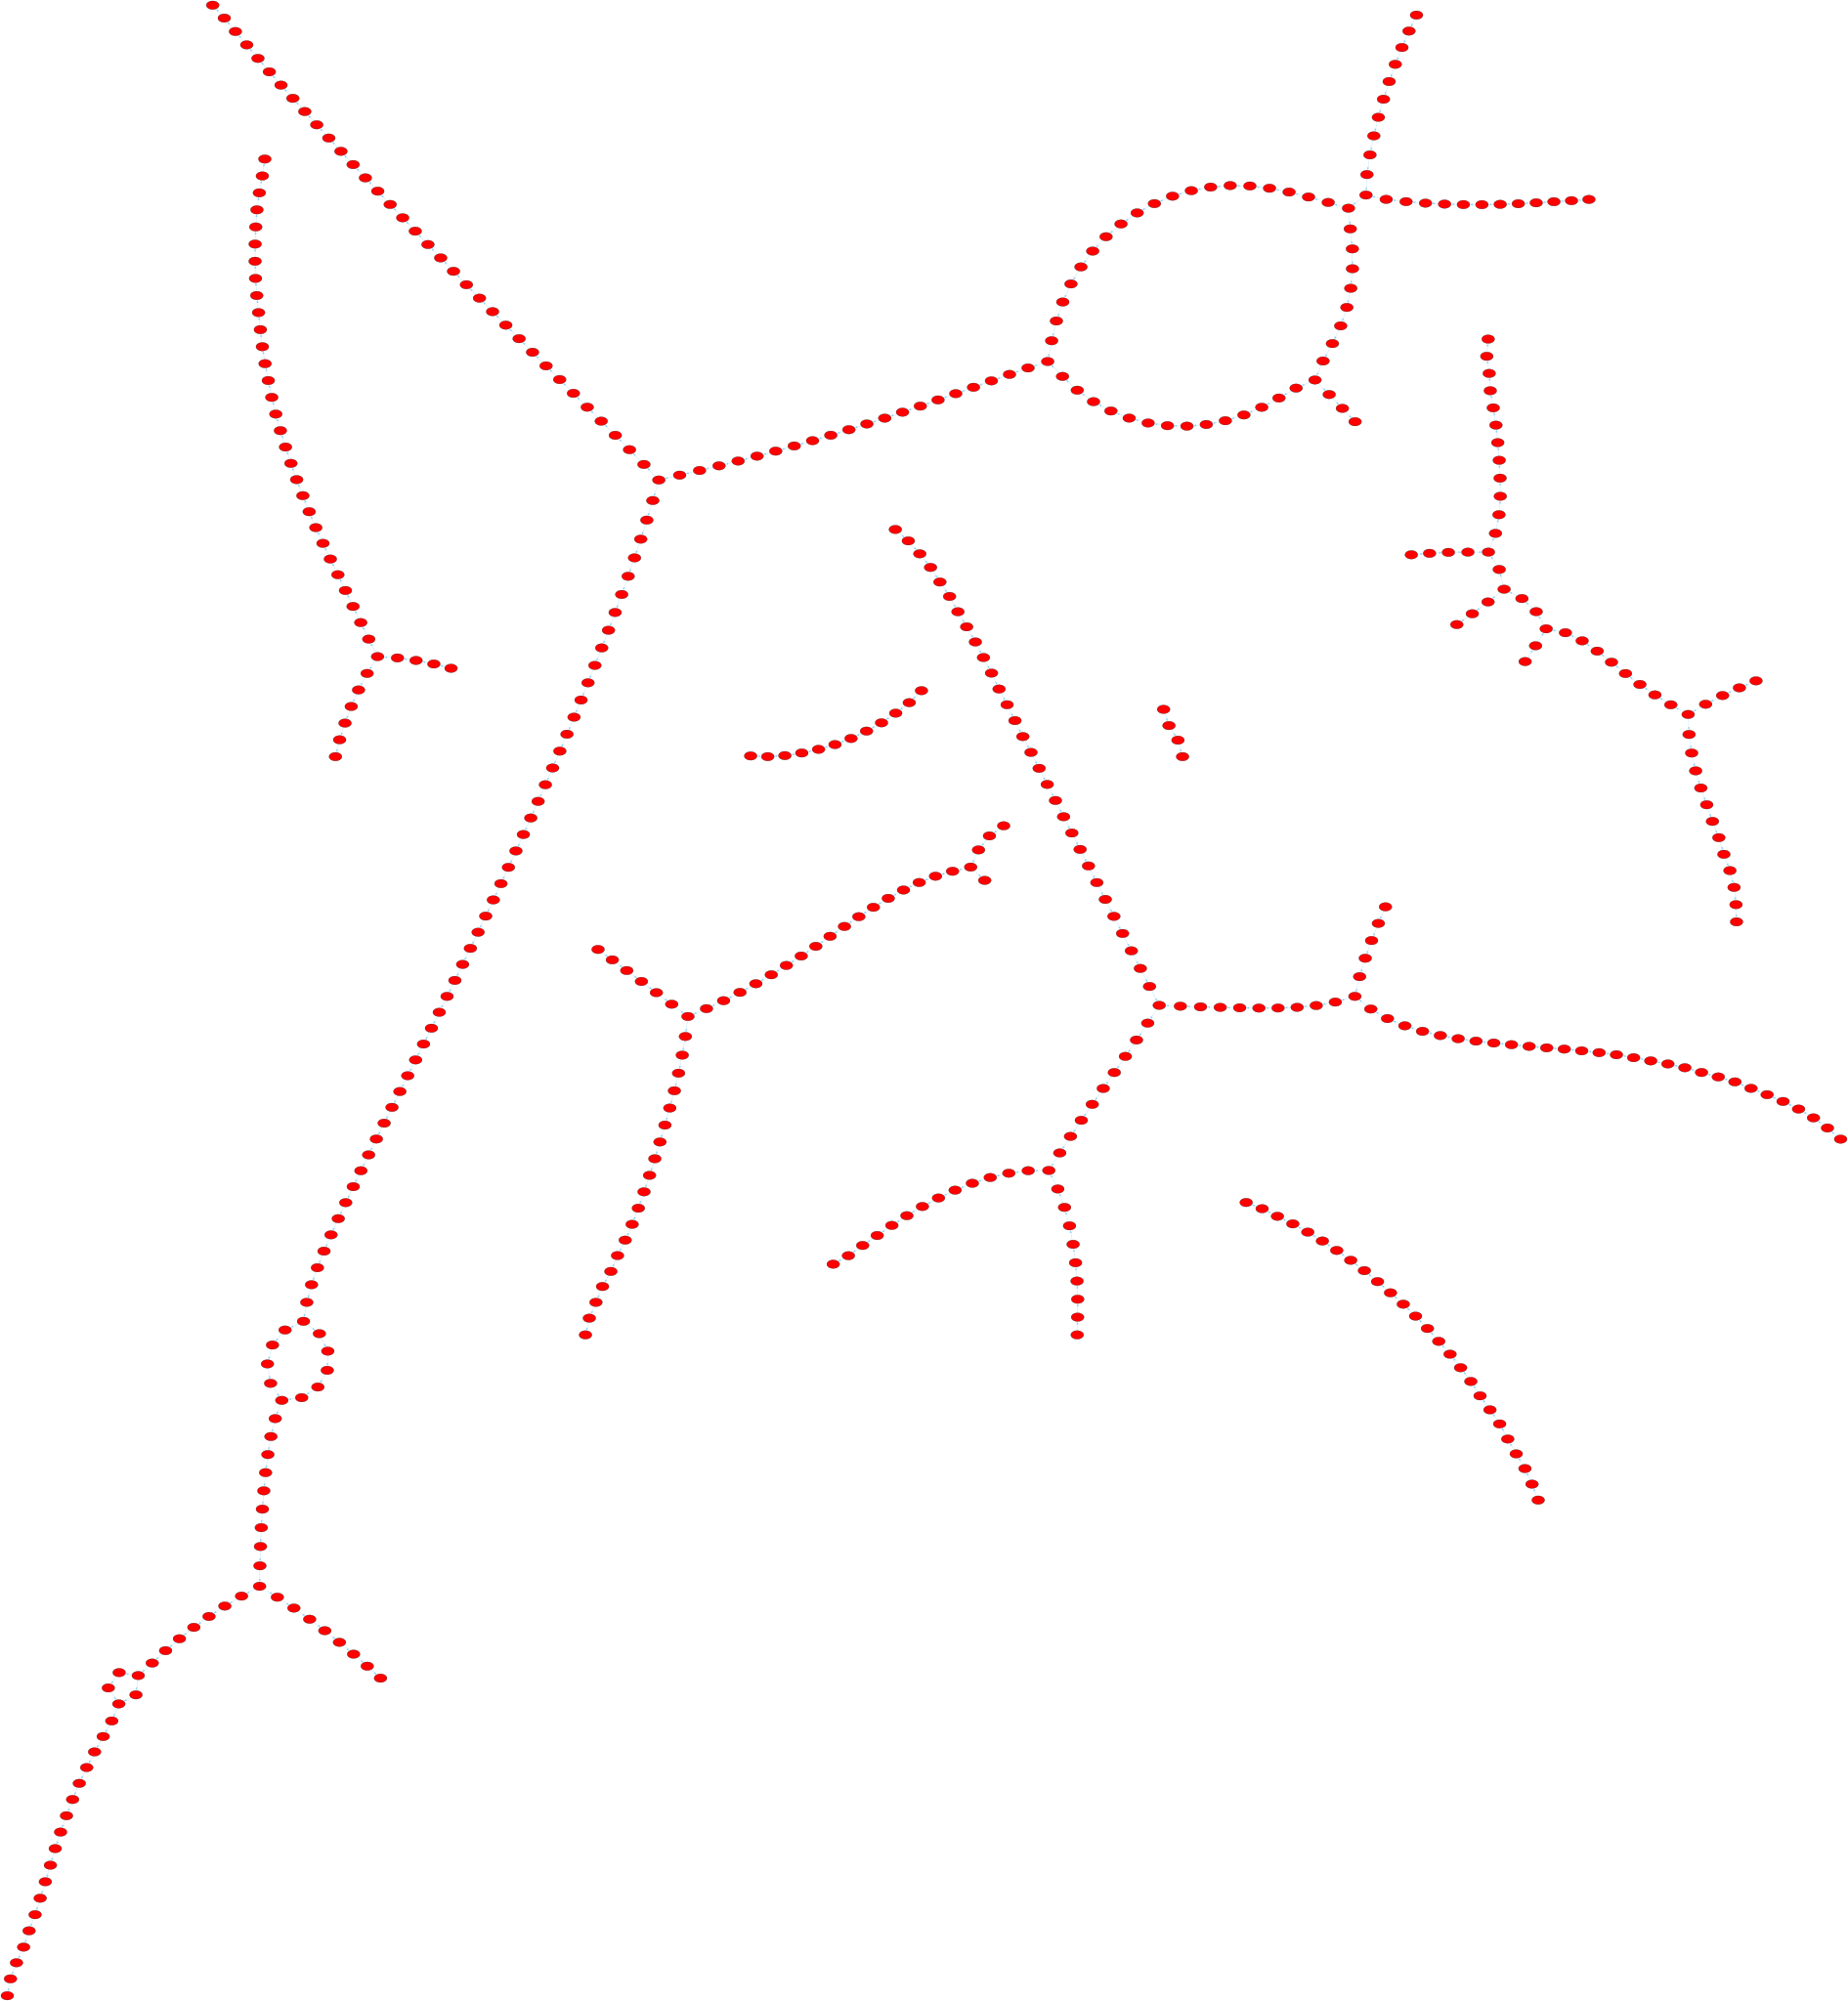

In [9]:
g = AcyclicGraphDNA.draw_solution(graphs, strand_graph, strand_graph_undirected, part_map, solve_edges, show_all_edges=False)
g.engine = 'neato'
g


Post-processing and benchmarking using QUAST

In [7]:
results_file = "results-SA.pkl"

!sed -i '' "s/^RESULTS_PKL=.*/RESULTS_PKL=\"$results_file\"/" run_pipeline_copy.sh
!bash run_pipeline_copy.sh

segments: 524, links: 4642, containments: 0, lines: 5166

nodes quantity: 1048
Processing solution  0
Processing 0
[W] overlap length longer than segment length for 'ERR13577262.3041:1-67620': 67925 > 67620
[M::main] Version: 0.4-r214-dirty
[M::main] CMD: gfatools asm -u output_0.gfa
[M::main] Real time: 0.014 sec; CPU: 0.017 sec
[M::mm_idx_gen::0.075*1.02] collected minimizers
[M::mm_idx_gen::0.090*2.46] sorted minimizers
[M::main::0.090*2.46] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.100*2.31] mid_occ = 10
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.108*2.21] distinct minimizers: 1102537 (92.03% are singletons); average occurrences: 1.109; average spacing: 5.357; total length: 6552573
[M::worker_pipeline::3.415*8.44] mapped 21969 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -t 16 0_merged_unitigs.fa ERR13577262.fastq
[M::main] Real time: 3.420 sec; CPU: 28.829 sec; Peak RSS: 0.381 GB
[racon::Polisher

In [4]:
# load the entire transposed report once
df = pd.read_csv("circ_report_ideal.tsv", sep="\t", index_col=0)
# "combined_quast/report-ideal-HADOF.tsv"
# list of assembly IDs (columns in df) except the first label column
assembly_ids = df.columns.tolist()

records = []
for aid in assembly_ids:
    rec = {
        "assembly": aid,
        "contigs": df.loc["# contigs (>= 0 bp)", aid],
        "total_length": df.loc["Total length", aid],
        "largest_contig": df.loc["Largest contig", aid],
        "genome_frac": df.loc["Genome fraction (%)", aid],
        "largest_aln": df.loc["Largest alignment", aid],
        "total_aln": df.loc["Total aligned length", aid],
        "misassemblies": df.loc["# misassemblies", aid],
        "duplication_ratio": df.loc["Duplication ratio", aid]
        
    }
    records.append(rec)

metrics_df = pd.DataFrame(records)
for i in range(len(metrics_df["assembly"])):
    metrics_df["assembly"][i] = str(i)+"_polished_assembly"


# load the entire transposed report once
df1 = pd.read_csv("circ_report_sa.tsv", sep="\t", index_col=0)
# "combined_quast/report-SA.tsv"

# list of assembly IDs (columns in df) except the first label column
assembly_ids1 = df1.columns.tolist()

records1 = []
for aid in assembly_ids1:
    rec1 = {
        "assembly": aid,
        "contigs": df1.loc["# contigs (>= 0 bp)", aid],
        "total_length": df1.loc["Total length", aid],
        "largest_contig": df1.loc["Largest contig", aid],
        "genome_frac": df1.loc["Genome fraction (%)", aid],
        "largest_aln": df1.loc["Largest alignment", aid],
        "total_aln": df1.loc["Total aligned length", aid],
        "misassemblies": df1.loc["# misassemblies", aid],
        "duplication_ratio": df1.loc["Duplication ratio", aid]
        # "mismatches": df.loc["Mismatches per 100 kb", aid],
    }
    records1.append(rec1)

metrics_df1 = pd.DataFrame(records1)
for i in range(len(metrics_df1["assembly"])):
    metrics_df1["assembly"][i] = str(i)+"_polished_assembly"


df2 = pd.read_csv("circ_report.tsv", sep="\t", index_col=0)
# "combined_quast/report-real-device.tsv"
# list of assembly IDs (columns in df) except the first label column
assembly_ids2 = df2.columns.tolist()

records2 = []
for aid in assembly_ids2:
    rec2 = {
        "assembly": aid,
        "contigs": df2.loc["# contigs (>= 0 bp)", aid],
        "total_length": df2.loc["Total length", aid],
        "largest_contig": df2.loc["Largest contig", aid],
        "genome_frac": df2.loc["Genome fraction (%)", aid],
        "largest_aln": df2.loc["Largest alignment", aid],
        "total_aln": df2.loc["Total aligned length", aid],
        "misassemblies": df2.loc["# misassemblies", aid],
        "duplication_ratio": df2.loc["Duplication ratio", aid],
        # "mismatches": df.loc["Mismatches per 100 kb", aid],
    }
    records2.append(rec2)

metrics_df2 = pd.DataFrame(records2)
for i in range(len(metrics_df2["assembly"])):
    metrics_df2["assembly"][i] = str(i)+"_polished_assembly"

/var/folders/ws/f8jjddps60qbw5v5wvlcrf8w0000gn/T/ipykernel_43185/3643442198.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metrics_df["assembly"][i] = str(i)+"_polished_assembly"
/var/folders/ws/f8jjddps60qbw5v5wvlcrf8w0000gn/T/ipykern

In [5]:
with open("results-ideal-HADOF.pkl", "rb") as f:
    sols = pickle.load(f)
for i in range(len(sols[2])):
    sols[2][i] = np.array(sols[2][i])
sols[0] = np.array(sols[0])

with open("results-SA.pkl", "rb") as f:
    sols1 = pickle.load(f)

for i in range(len(sols1[2])-1):
    sols1[2][i] = np.array(list(sols1[2][i].values()))
sols1[0] = np.array(list(sols1[0].values()))

with open("results-real-device.pkl", "rb") as f:
    sols2 = pickle.load(f)
for i in range(len(sols2[2])):
    sols2[2][i] = np.array(sols2[2][i])
sols2[0] = np.array(sols2[0])

In [6]:
metrics_df["total_length"] = pd.to_numeric(metrics_df["total_length"])
metrics_df["largest_contig"] = pd.to_numeric(metrics_df["largest_contig"])
metrics_df["genome_frac"] = pd.to_numeric(metrics_df["genome_frac"])
metrics_df["largest_aln"] = pd.to_numeric(metrics_df["largest_aln"])
metrics_df["total_aln"] = pd.to_numeric(metrics_df["total_aln"])
metrics_df["misassemblies"] = pd.to_numeric(metrics_df["misassemblies"])
metrics_df["duplication_ratio"] = pd.to_numeric(metrics_df["duplication_ratio"])

metrics_df1["total_length"] = pd.to_numeric(metrics_df1["total_length"])
metrics_df1["largest_contig"] = pd.to_numeric(metrics_df1["largest_contig"])
metrics_df1["genome_frac"] = pd.to_numeric(metrics_df1["genome_frac"])
metrics_df1["largest_aln"] = pd.to_numeric(metrics_df1["largest_aln"])
metrics_df1["total_aln"] = pd.to_numeric(metrics_df1["total_aln"])
metrics_df1["misassemblies"] = pd.to_numeric(metrics_df1["misassemblies"])
metrics_df1["duplication_ratio"] = pd.to_numeric(metrics_df1["duplication_ratio"])

metrics_df2["total_length"] = pd.to_numeric(metrics_df2["total_length"])
metrics_df2["largest_contig"] = pd.to_numeric(metrics_df2["largest_contig"])
metrics_df2["genome_frac"] = pd.to_numeric(metrics_df2["genome_frac"])
metrics_df2["largest_aln"] = pd.to_numeric(metrics_df2["largest_aln"])
metrics_df2["total_aln"] = pd.to_numeric(metrics_df2["total_aln"])
metrics_df2["misassemblies"] = pd.to_numeric(metrics_df2["misassemblies"])
metrics_df2["duplication_ratio"] = pd.to_numeric(metrics_df2["duplication_ratio"])

In [18]:
Q_matrix = np.array(Q) 

qubo_score = []
genome_frac = []
total_length = []
largest_contig = []
largest_aln = []
total_aln = []
duplication = []

qubo_score1 = []
genome_frac1 = []
total_length1 = []
largest_contig1 = []
largest_aln1 = []
total_aln1 = []
duplication1 = []

qubo_score2 = []
genome_frac2 = []
total_length2 = []
largest_contig2 = []
largest_aln2 = []
total_aln2 = []
duplication2 = []



for i in range(5000):
    print(i)
    if (metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"].empty):
        continue
    else:
        if i == 0:
            # qubo_score.append(evaluate_penalty(qubo_dict, 2313, sols[0]))
            qubo_score.append(sols[0] @ Q_matrix @ sols[0])
        else:
            # qubo_score.append(evaluate_penalty(qubo_dict, 2313, sols[2][i-1]))
            qubo_score.append(sols[2][i-1] @ Q_matrix @ sols[2][i-1])
        genome_frac.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["genome_frac"].values[0]))
        total_length.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["total_length"].values[0]))
        largest_contig.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["largest_contig"].values[0]))
        largest_aln.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["largest_aln"].values[0]))
        total_aln.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["total_aln"].values[0]))
        duplication.append(float(metrics_df[metrics_df["assembly"]==f"{i}_polished_assembly"]["duplication_ratio"].values[0]))
    
for i in range(5000):
    print(i)
    if (metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"].empty):
        continue
    else:
        if i == 0:
            qubo_score1.append(sols1[0] @ Q_matrix @ sols1[0])
        else:
            qubo_score1.append(sols1[2][i-1] @ Q_matrix @ sols1[2][i-1])
        genome_frac1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["genome_frac"].values[0]))
        total_length1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["total_length"].values[0]))
        largest_contig1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["largest_contig"].values[0]))
        largest_aln1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["largest_aln"].values[0]))
        total_aln1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["total_aln"].values[0]))
        duplication1.append(float(metrics_df1[metrics_df1["assembly"]==f"{i}_polished_assembly"]["duplication_ratio"].values[0]))

for i in range(5000):
    print(i)
    if (metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"].empty):
        continue
    else:
        if i == 0:
            qubo_score2.append(sols2[0] @ Q_matrix @ sols2[0])
        else:
            qubo_score2.append(sols2[2][i-1] @ Q_matrix @ sols2[2][i-1])
        genome_frac2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["genome_frac"].values[0]))
        total_length2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["total_length"].values[0]))
        largest_contig2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["largest_contig"].values[0]))
        largest_aln2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["largest_aln"].values[0]))
        total_aln2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["total_aln"].values[0]))
        duplication2.append(float(metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"]["duplication_ratio"].values[0]))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [19]:
def compute_degrees(edge_list):
    in_deg = defaultdict(int)
    out_deg = defaultdict(int)
    nodes = set()

    for u, v in edge_list:
        out_deg[u] += 1
        in_deg[v] += 1
        nodes.add(u)
        nodes.add(v)

    # ensure zero-degree nodes appear
    for n in nodes:
        in_deg[n] += 0
        out_deg[n] += 0

    return in_deg, out_deg, nodes

def build_adj_out(edges):
    adj = defaultdict(list)
    for u, v in edges:
        adj[u].append(v)
    return adj


def build_adj_in(edges):
    adj = defaultdict(list)
    for u, v in edges:
        adj[v].append(u)
    return adj


def longest_path_from(node, adj, node_lengths, memo, visiting):
    # Already solved
    res=0
    # print("current node", node_labels[node])
    if node in memo:
        return memo[node]

    # Cycle detected → cut
    if node in visiting:
        w = 0
        visiting = set()
        return res

    visiting.add(node)

    # Handle list-based node_lengths safely
    w = node_lengths[node]


    children = adj.get(node, [])


    if not children:
        res = res + w
    else:
        res = res + w + max(
            longest_path_from(v, adj, node_lengths, memo, visiting)
            for v in children
        )

    visiting = set()

    memo[node] = res
    return res

def enforce_linear(scored_edges):
    used_sinks = set()
    used_sources = set()
    kept = []

    for u, v in scored_edges:
        if u not in used_sinks and v not in used_sources:
            kept.append([u, v])
            used_sinks.add(u)
            used_sources.add(v)

    return kept

def longest_nodes_from(node, adj, memo, visiting):
    # Already solved
    res=0
    # print("current node", node_labels[node])
    if node in memo:
        return memo[node]

    # Cycle detected → cut
    if node in visiting:
        w = 0
        visiting = set()
        return res

    visiting.add(node)

    # Handle list-based node_lengths safely
    w = 1


    children = adj.get(node, [])


    if not children:
        res = res + w
    else:
        res = res + w + max(
            longest_nodes_from(v, adj, memo, visiting)
            for v in children
        )

    visiting = set()

    memo[node] = res
    return res

In [20]:
nodes_total= []
for i in range(5000):
    print(i)
    if i == 0:
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols[0])):
            if sols[0][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part
    else:
        sol_no = i-1
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols[2][sol_no])):
            if sols[2][sol_no][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part

    in_deg, out_deg, sub_nodes = compute_degrees(solve_edges_idices)
    check_nodes_out = [n for n in sub_nodes if out_deg[n] > 1]
    check_edges_out = [[u, v] for u, v in solve_edges_idices if u in check_nodes_out]
    check_nodes_in = [n for n in sub_nodes if in_deg[n] > 1]
    check_edges_in = [[u, v] for u, v in solve_edges_idices if v in check_nodes_in]

    adj_out = build_adj_out(solve_edges_idices)
    adj_in = build_adj_in(solve_edges_idices)


    memo = {}

    targets = check_edges_out

    path_len = {
        v: longest_path_from(v, adj_out, node_lengths, memo, set())
        for _, v in targets
    }

    scored = sorted(
        check_edges_out,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    recovered_edges_out = enforce_linear(scored)

    memo = {}

    targets = check_edges_in

    path_len = {
        u: longest_path_from(u, adj_in, node_lengths, memo, set())
        for u, _ in targets
    }

    scored = sorted(
        check_edges_in,
        key=lambda e: path_len[e[0]],
        reverse=True
    )
    recovered_edges_in = enforce_linear(scored)
    repaired_edges_out = [[u, v] for u, v in solve_edges_idices if ([u, v] not in check_edges_out or [u, v] in recovered_edges_out)]
    repaired_edges = [[u, v] for u, v in repaired_edges_out if [u, v] not in check_edges_in or [u, v] in recovered_edges_in]

    in_deg, out_deg, sub_nodes = compute_degrees(repaired_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}
    bad_nodes = {n for n in nodes_indices if n not in sub_nodes}
    sinks = sinks.union(bad_nodes)
    sources = sources.union(bad_nodes)

    reconnecting_edges = [
        [u, v]
        for u, v in edges
        if u in sinks and v in sources
    ]

    adj_out = build_adj_out(repaired_edges)
    # adj_out = build_adj_out(solve_edges_idices)
    memo = {}
    path_len = {v: longest_path_from(v, adj_out, node_lengths, memo, set()) for _, v in reconnecting_edges}
    scored = sorted(
        reconnecting_edges,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    connections = enforce_linear(scored)

    final_edges = repaired_edges + connections

    in_deg, out_deg, sub_nodes = compute_degrees(final_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}

    memo={}
    adj_out = build_adj_out(final_edges)
    path_len = {v: longest_nodes_from(v, adj_out, memo, set()) for v in sources}

    # chosen_paths = [list(path_len.keys())[i] for i in range(len(path_len)) if list(path_len.values())[i]>40] 
    chosen_paths = [max(path_len, key=path_len.get)]
    if chosen_paths:

        newfinal_edges = []
        for path in chosen_paths:
            node = path
            while node in adj_out and adj_out[node]:
                newfinal_edges.append([node, adj_out[node][0]])
                node = adj_out[node][0]   

        solve_edges = []
        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in newfinal_edges]
        solve_edges+=solve_edges_part
        nodes_total.append(len(solve_edges)+1)








nodes_total1= []
for i in range(5000):
    print(i)
    if i == 0:
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols1[0])):
            if sols1[0][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part
    else:
        sol_no = i-1
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols1[2][sol_no])):
            if sols1[2][sol_no][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part

    in_deg, out_deg, sub_nodes = compute_degrees(solve_edges_idices)
    check_nodes_out = [n for n in sub_nodes if out_deg[n] > 1]
    check_edges_out = [[u, v] for u, v in solve_edges_idices if u in check_nodes_out]
    check_nodes_in = [n for n in sub_nodes if in_deg[n] > 1]
    check_edges_in = [[u, v] for u, v in solve_edges_idices if v in check_nodes_in]

    adj_out = build_adj_out(solve_edges_idices)
    adj_in = build_adj_in(solve_edges_idices)


    memo = {}

    targets = check_edges_out

    path_len = {
        v: longest_path_from(v, adj_out, node_lengths, memo, set())
        for _, v in targets
    }

    scored = sorted(
        check_edges_out,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    recovered_edges_out = enforce_linear(scored)

    memo = {}

    targets = check_edges_in

    path_len = {
        u: longest_path_from(u, adj_in, node_lengths, memo, set())
        for u, _ in targets
    }

    scored = sorted(
        check_edges_in,
        key=lambda e: path_len[e[0]],
        reverse=True
    )
    recovered_edges_in = enforce_linear(scored)
    repaired_edges_out = [[u, v] for u, v in solve_edges_idices if ([u, v] not in check_edges_out or [u, v] in recovered_edges_out)]
    repaired_edges = [[u, v] for u, v in repaired_edges_out if [u, v] not in check_edges_in or [u, v] in recovered_edges_in]

    in_deg, out_deg, sub_nodes = compute_degrees(repaired_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}
    bad_nodes = {n for n in nodes_indices if n not in sub_nodes}
    sinks = sinks.union(bad_nodes)
    sources = sources.union(bad_nodes)

    reconnecting_edges = [
        [u, v]
        for u, v in edges
        if u in sinks and v in sources
    ]

    adj_out = build_adj_out(repaired_edges)
    # adj_out = build_adj_out(solve_edges_idices)
    memo = {}
    path_len = {v: longest_path_from(v, adj_out, node_lengths, memo, set()) for _, v in reconnecting_edges}
    scored = sorted(
        reconnecting_edges,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    connections = enforce_linear(scored)

    final_edges = repaired_edges + connections

    in_deg, out_deg, sub_nodes = compute_degrees(final_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}

    memo={}
    adj_out = build_adj_out(final_edges)
    path_len = {v: longest_nodes_from(v, adj_out, memo, set()) for v in sources}

    # chosen_paths = [list(path_len.keys())[i] for i in range(len(path_len)) if list(path_len.values())[i]>40] 
    chosen_paths = [max(path_len, key=path_len.get)]
    if chosen_paths:

        newfinal_edges = []
        for path in chosen_paths:
            node = path
            while node in adj_out and adj_out[node]:
                newfinal_edges.append([node, adj_out[node][0]])
                node = adj_out[node][0]   

        solve_edges = []
        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in newfinal_edges]
        solve_edges+=solve_edges_part
        nodes_total1.append(len(solve_edges)+1)



nodes_total2= []
for i in range(5000):
    if (metrics_df2[metrics_df2["assembly"]==f"{i}_polished_assembly"].empty):
        continue
    print(i)
    if i == 0:
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols2[0])):
            if sols2[0][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part
    else:
        sol_no = i-1
        solve_edges=[]
        solve_edges_idices=[]
        for key in range(len(sols2[2][sol_no])):
            if sols2[2][sol_no][key]==1:
                solve_edges_idices.append(edges_indices[key])

        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
        solve_edges+=solve_edges_part

    in_deg, out_deg, sub_nodes = compute_degrees(solve_edges_idices)
    check_nodes_out = [n for n in sub_nodes if out_deg[n] > 1]
    check_edges_out = [[u, v] for u, v in solve_edges_idices if u in check_nodes_out]
    check_nodes_in = [n for n in sub_nodes if in_deg[n] > 1]
    check_edges_in = [[u, v] for u, v in solve_edges_idices if v in check_nodes_in]

    adj_out = build_adj_out(solve_edges_idices)
    adj_in = build_adj_in(solve_edges_idices)


    memo = {}

    targets = check_edges_out

    path_len = {
        v: longest_path_from(v, adj_out, node_lengths, memo, set())
        for _, v in targets
    }

    scored = sorted(
        check_edges_out,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    recovered_edges_out = enforce_linear(scored)

    memo = {}

    targets = check_edges_in

    path_len = {
        u: longest_path_from(u, adj_in, node_lengths, memo, set())
        for u, _ in targets
    }

    scored = sorted(
        check_edges_in,
        key=lambda e: path_len[e[0]],
        reverse=True
    )
    recovered_edges_in = enforce_linear(scored)
    repaired_edges_out = [[u, v] for u, v in solve_edges_idices if ([u, v] not in check_edges_out or [u, v] in recovered_edges_out)]
    repaired_edges = [[u, v] for u, v in repaired_edges_out if [u, v] not in check_edges_in or [u, v] in recovered_edges_in]

    in_deg, out_deg, sub_nodes = compute_degrees(repaired_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}
    bad_nodes = {n for n in nodes_indices if n not in sub_nodes}
    sinks = sinks.union(bad_nodes)
    sources = sources.union(bad_nodes)

    reconnecting_edges = [
        [u, v]
        for u, v in edges
        if u in sinks and v in sources
    ]

    adj_out = build_adj_out(repaired_edges)
    # adj_out = build_adj_out(solve_edges_idices)
    memo = {}
    path_len = {v: longest_path_from(v, adj_out, node_lengths, memo, set()) for _, v in reconnecting_edges}
    scored = sorted(
        reconnecting_edges,
        key=lambda e: path_len[e[1]],
        reverse=True
    )

    connections = enforce_linear(scored)

    final_edges = repaired_edges + connections

    in_deg, out_deg, sub_nodes = compute_degrees(final_edges)
    sinks   = {n for n in sub_nodes if out_deg[n] == 0}
    sources = {n for n in sub_nodes if in_deg[n] == 0}

    memo={}
    adj_out = build_adj_out(final_edges)
    path_len = {v: longest_nodes_from(v, adj_out, memo, set()) for v in sources}

    # chosen_paths = [list(path_len.keys())[i] for i in range(len(path_len)) if list(path_len.values())[i]>40] 
    chosen_paths = [max(path_len, key=path_len.get)]
    if chosen_paths:

        newfinal_edges = []
        for path in chosen_paths:
            node = path
            while node in adj_out and adj_out[node]:
                newfinal_edges.append([node, adj_out[node][0]])
                node = adj_out[node][0]   

        solve_edges = []
        node_labels = list(pg.nodes)
        solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in newfinal_edges]
        solve_edges+=solve_edges_part
        nodes_total2.append(len(solve_edges)+1)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

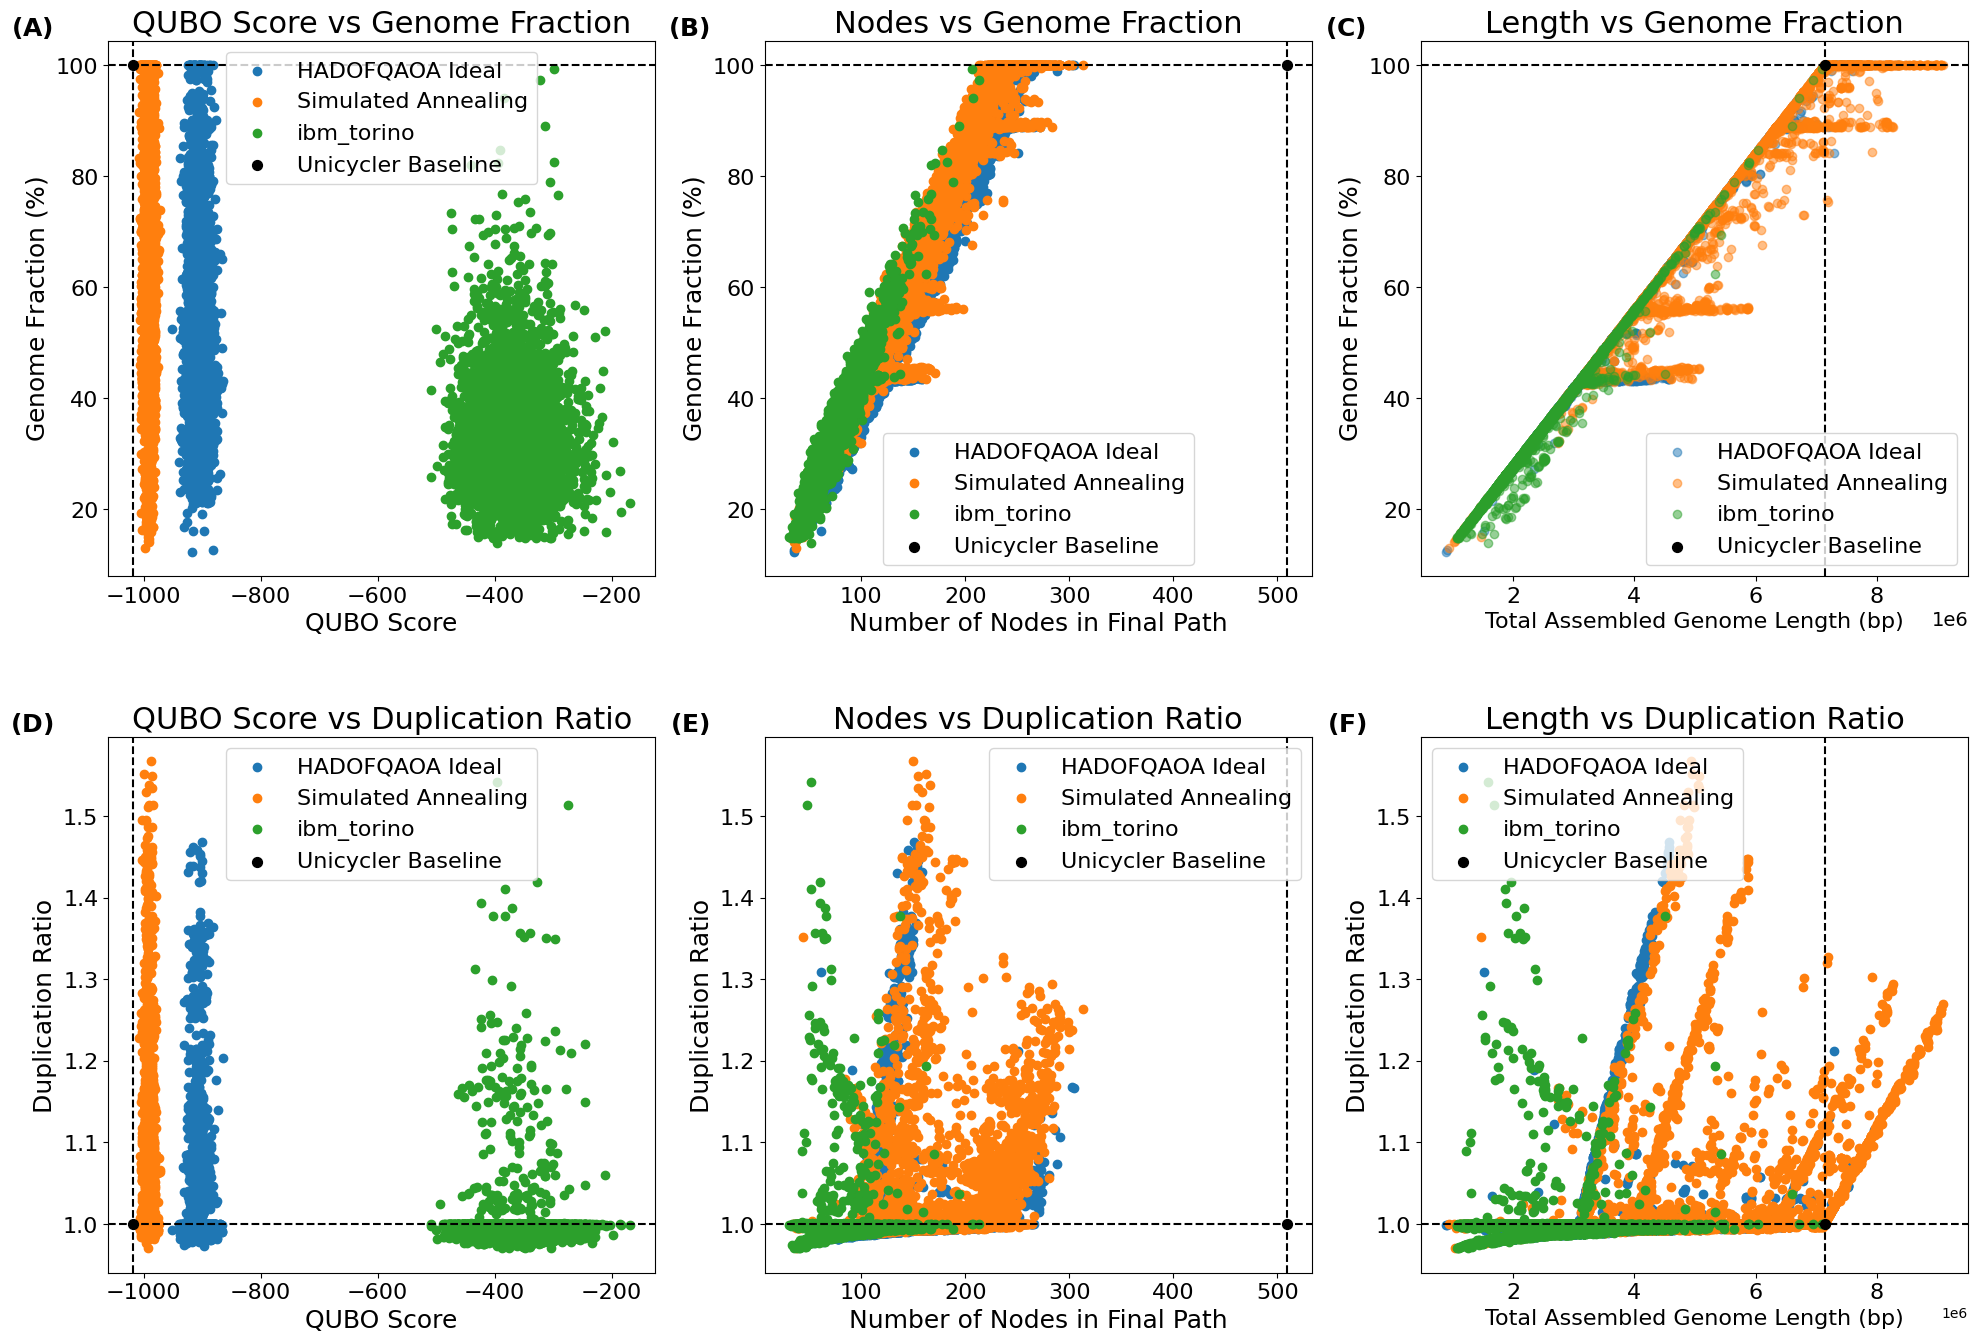

In [22]:
# --- FIGURE 1: (A), (B), (C) ---
fig1, axes1 = plt.subplots(2, 3, figsize=(24, 16))

fig1.subplots_adjust(
    hspace=0.30   # space between rows
    # wspace=0.25    # space between columns
)
# Helper list for labels
labels1 = [['(A)', '(B)', '(C)'], ['(D)', '(E)', '(F)']]

# (A) QUBO Score vs Total Length
ax = axes1[0, 0]
ax.scatter(qubo_score, genome_frac, label='HADOFQAOA Ideal')
ax.scatter(qubo_score1, genome_frac1, label='Simulated Annealing')
ax.scatter(qubo_score2[1:], genome_frac2[1:], label='ibm_torino')
ax.scatter(-1018, 100, color='black', label='Unicycler Baseline', s=50)
ax.axvline(x=-1018, color='black', linestyle='--')
ax.axhline(y=100, color='black', linestyle='--')
ax.set_xlabel("QUBO Score", fontsize=18)
ax.set_ylabel("Genome Fraction $(\%)$", fontsize=18)
ax.set_title("QUBO Score vs Genome Fraction", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.xaxis.get_offset_text().set_fontsize(14)
ax.yaxis.get_offset_text().set_fontsize(14)
ax.legend(fontsize=16)

# (B) QUBO Score vs Genome Fraction
ax = axes1[0, 1]
ax.scatter(nodes_total, genome_frac, label='HADOFQAOA Ideal')
ax.scatter(nodes_total1, genome_frac1, label='Simulated Annealing')
ax.scatter(nodes_total2[1:], genome_frac2[1:], label='ibm_torino')
ax.scatter(509, 100, color='black', label='Unicycler Baseline', s=50)
ax.axvline(x=509, color='black', linestyle='--')
ax.axhline(y=100, color='black', linestyle='--')
ax.set_xlabel("Number of Nodes in Final Path", fontsize=18)
ax.set_ylabel("Genome Fraction $(\%)$", fontsize=18)
ax.set_title("Nodes vs Genome Fraction", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=16)

# (C) Total Length vs Genome Fraction
ax = axes1[0, 2]
ax.scatter(total_length, genome_frac, alpha=0.5, label='HADOFQAOA Ideal')
ax.scatter(total_length1, genome_frac1, alpha=0.5, label='Simulated Annealing')
ax.scatter(total_length2, genome_frac2, alpha=0.5, label='ibm_torino')
ax.scatter(7139404, 100, color='black', label='Unicycler Baseline', s=50)
ax.axvline(x=7139404, color='black', linestyle='--')
ax.axhline(y=100, color='black', linestyle='--')
ax.set_xlabel("Total Assembled Genome Length (bp)", fontsize=16)
ax.set_ylabel("Genome Fraction $(\%)$", fontsize=18)
ax.set_title("Length vs Genome Fraction", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.xaxis.get_offset_text().set_fontsize(14)
ax.yaxis.get_offset_text().set_fontsize(14)
ax.legend(fontsize=16)





# # (D) QUBO Score vs Matching Edges
# ax = axes2[0]
# ax.scatter(qubo_score, [2313 - c for c in counts], label='HADOFQAOA Ideal')
# ax.scatter(qubo_score1, [2313 - c for c in counts1], label='Simulated Annealing')
# ax.scatter(qubo_score2[1:], [2313 - c for c in counts2[1:]], label='ibm_torino')
# ax.scatter(-1018, 2313, color='black', label='Unicycler Baseline', s=50)
# ax.axvline(x=-1018, color='black', linestyle='--')
# ax.axhline(y=2313, color='black', linestyle='--')
# ax.set_xlabel("QUBO Score", fontsize=18)
# ax.set_ylabel("Number of Matching Edges", fontsize=18)
# ax.set_title("QUBO Score vs Matching Edges", fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=16)
# ax.legend(fontsize=16)

# (E) QUBO Score vs Number of Nodes
ax = axes1[1, 0]
ax.scatter(qubo_score, duplication, label='HADOFQAOA Ideal')
ax.scatter(qubo_score1, duplication1, label='Simulated Annealing')
ax.scatter(qubo_score2[1:], duplication2[1:], label='ibm_torino')
ax.scatter(-1018, 1, color='black', label='Unicycler Baseline', s=50)
ax.axhline(y=1, color='black', linestyle='--')
ax.axvline(x=-1018, color='black', linestyle='--')
ax.set_xlabel("QUBO Score", fontsize=18)
ax.set_ylabel("Duplication Ratio", fontsize=18)
ax.set_title("QUBO Score vs Duplication Ratio", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=16)

# (F) Nodes Total vs Total Length
ax = axes1[1, 1]
ax.scatter(nodes_total, duplication, label='HADOFQAOA Ideal')
ax.scatter(nodes_total1, duplication1, label='Simulated Annealing')
ax.scatter(nodes_total2, duplication2, label='ibm_torino')
ax.scatter(509, 1, color='black', label='Unicycler Baseline', s=50)
ax.axhline(y=1, color='black', linestyle='--')
ax.axvline(x=509, color='black', linestyle='--')
ax.set_xlabel("Number of Nodes in Final Path", fontsize=18)
ax.set_ylabel("Duplication Ratio", fontsize=18)
ax.set_title("Nodes vs Duplication Ratio", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.xaxis.get_offset_text().set_fontsize(14)
ax.yaxis.get_offset_text().set_fontsize(14)
ax.legend(fontsize=16)

# (G) Nodes Total vs Genome Fraction
ax = axes1[1, 2]
ax.scatter(total_length, duplication, label='HADOFQAOA Ideal')
ax.scatter(total_length1, duplication1, label='Simulated Annealing')
ax.scatter(total_length2, duplication2, label='ibm_torino')
ax.scatter(7139404, 1, color='black', label='Unicycler Baseline', s=50)
ax.axvline(x=7139404, color='black', linestyle='--')
ax.axhline(y=1, color='black', linestyle='--')
ax.set_xlabel("Total Assembled Genome Length (bp)", fontsize=16)
ax.set_ylabel("Duplication Ratio", fontsize=18)
ax.set_title("Length vs Duplication Ratio", fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=16)

# Add bold (D), (E), (F), (G) labels
for i, ax in enumerate(axes1):
    for j in range(len(ax)):
        ax[j].text(-0.1, 1.05, r"$\mathbf{" + labels1[i][j] + r"}$", transform=ax[j].transAxes, 
            fontsize=18, fontweight='bold', va='top', ha='right')

plt.show()

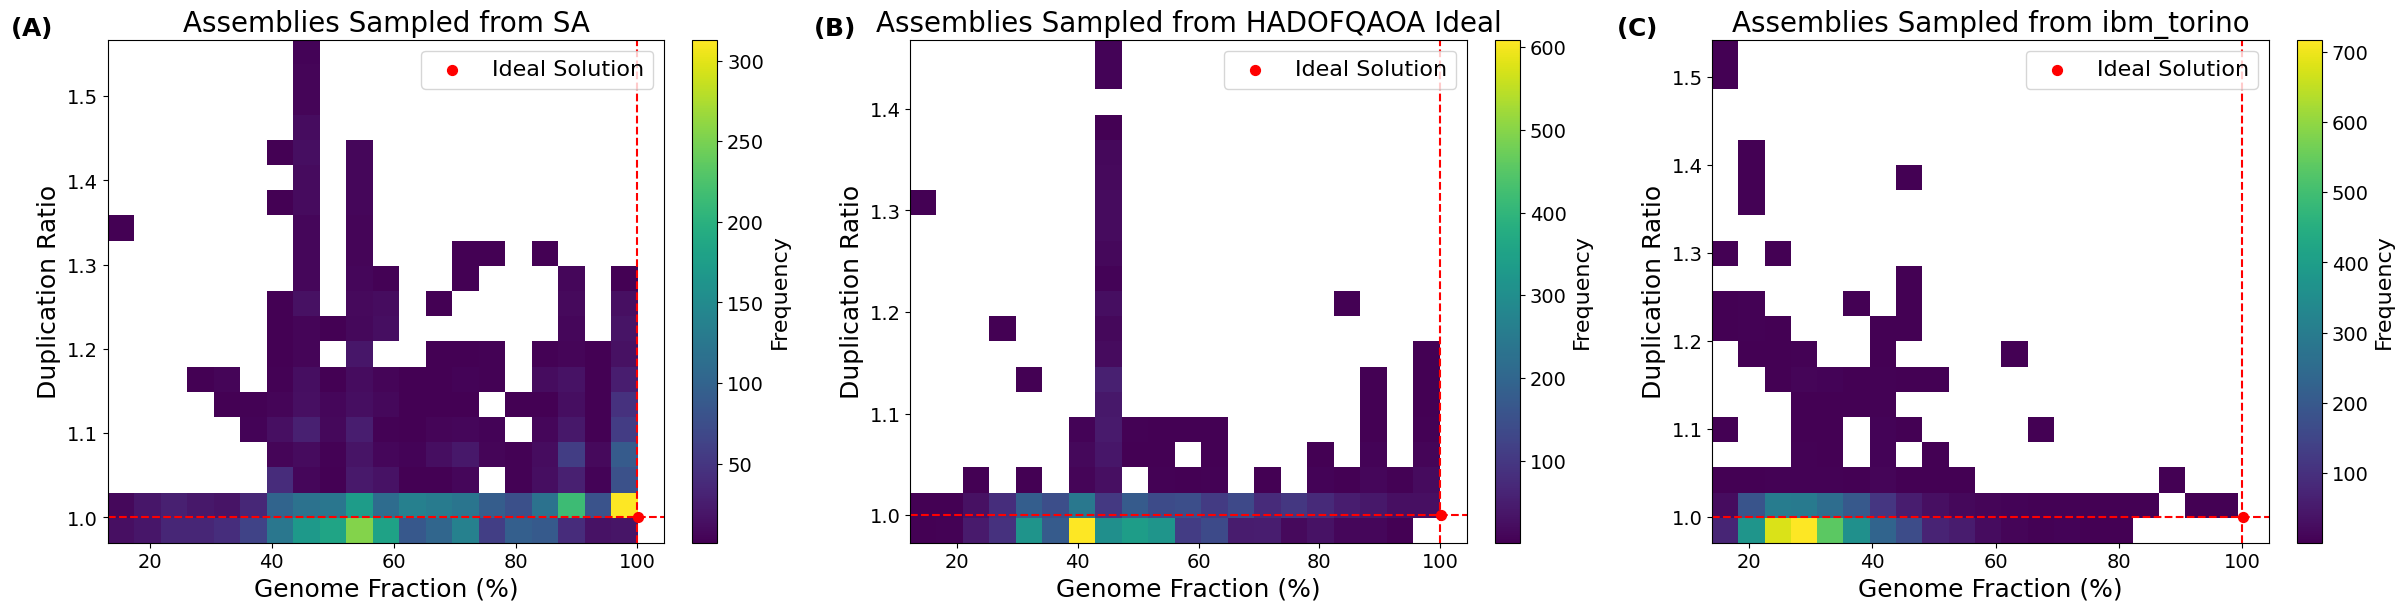

In [24]:
# --- FIGURE 1: (A), (B), (C) ---
fig1, axes1 = plt.subplots(
    1, 3,
    figsize=(24, 6),
    constrained_layout=True
)

labels1 = ['(A)', '(B)', '(C)']

datasets = [
    (metrics_df1["genome_frac"],  metrics_df1["duplication_ratio"],  "SA"),
    (metrics_df["genome_frac"], metrics_df["duplication_ratio"], "HADOFQAOA Ideal"),
    (metrics_df2["genome_frac"], metrics_df2["duplication_ratio"], "ibm_torino")
]

for i, (x, y, title) in enumerate(datasets):

    ax = axes1[i]

    x_bins = 20
    y_bins = 20

    H, x_edges, y_edges = np.histogram2d(
        x, y,
        bins=[x_bins, y_bins]
    )

    # Mask zero-frequency bins
    H_masked = np.ma.masked_where(H == 0, H)

    im = ax.imshow(
        H_masked.T,
        origin="lower",
        aspect="auto",
        extent=[
            x_edges[0], x_edges[-1],
            y_edges[0], y_edges[-1]
        ],
        cmap="viridis"
    )

    ax.set_xlabel("Genome Fraction (%)", fontsize=18)
    ax.set_ylabel("Duplication Ratio", fontsize=18)

    ax.set_title(
        f"Assemblies Sampled from {title}",
        fontsize=20
    )

    ax.tick_params(axis="both", labelsize=14)

    ax.scatter(100.05, 1, color='red', label='Ideal Solution', s=50)
    ax.axvline(x=100, color='red', linestyle='--')
    ax.axhline(y=1, color='red', linestyle='--')

    # Colourbar for each subplot
    cbar = fig1.colorbar(im, ax=ax)
    cbar.set_label("Frequency", fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    ax.legend(fontsize=16, loc="upper right")
    # Panel label
    ax.text(
        -0.1, 1.05,
        rf"$\mathbf{{{labels1[i]}}}$",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="right"
    )

plt.show()

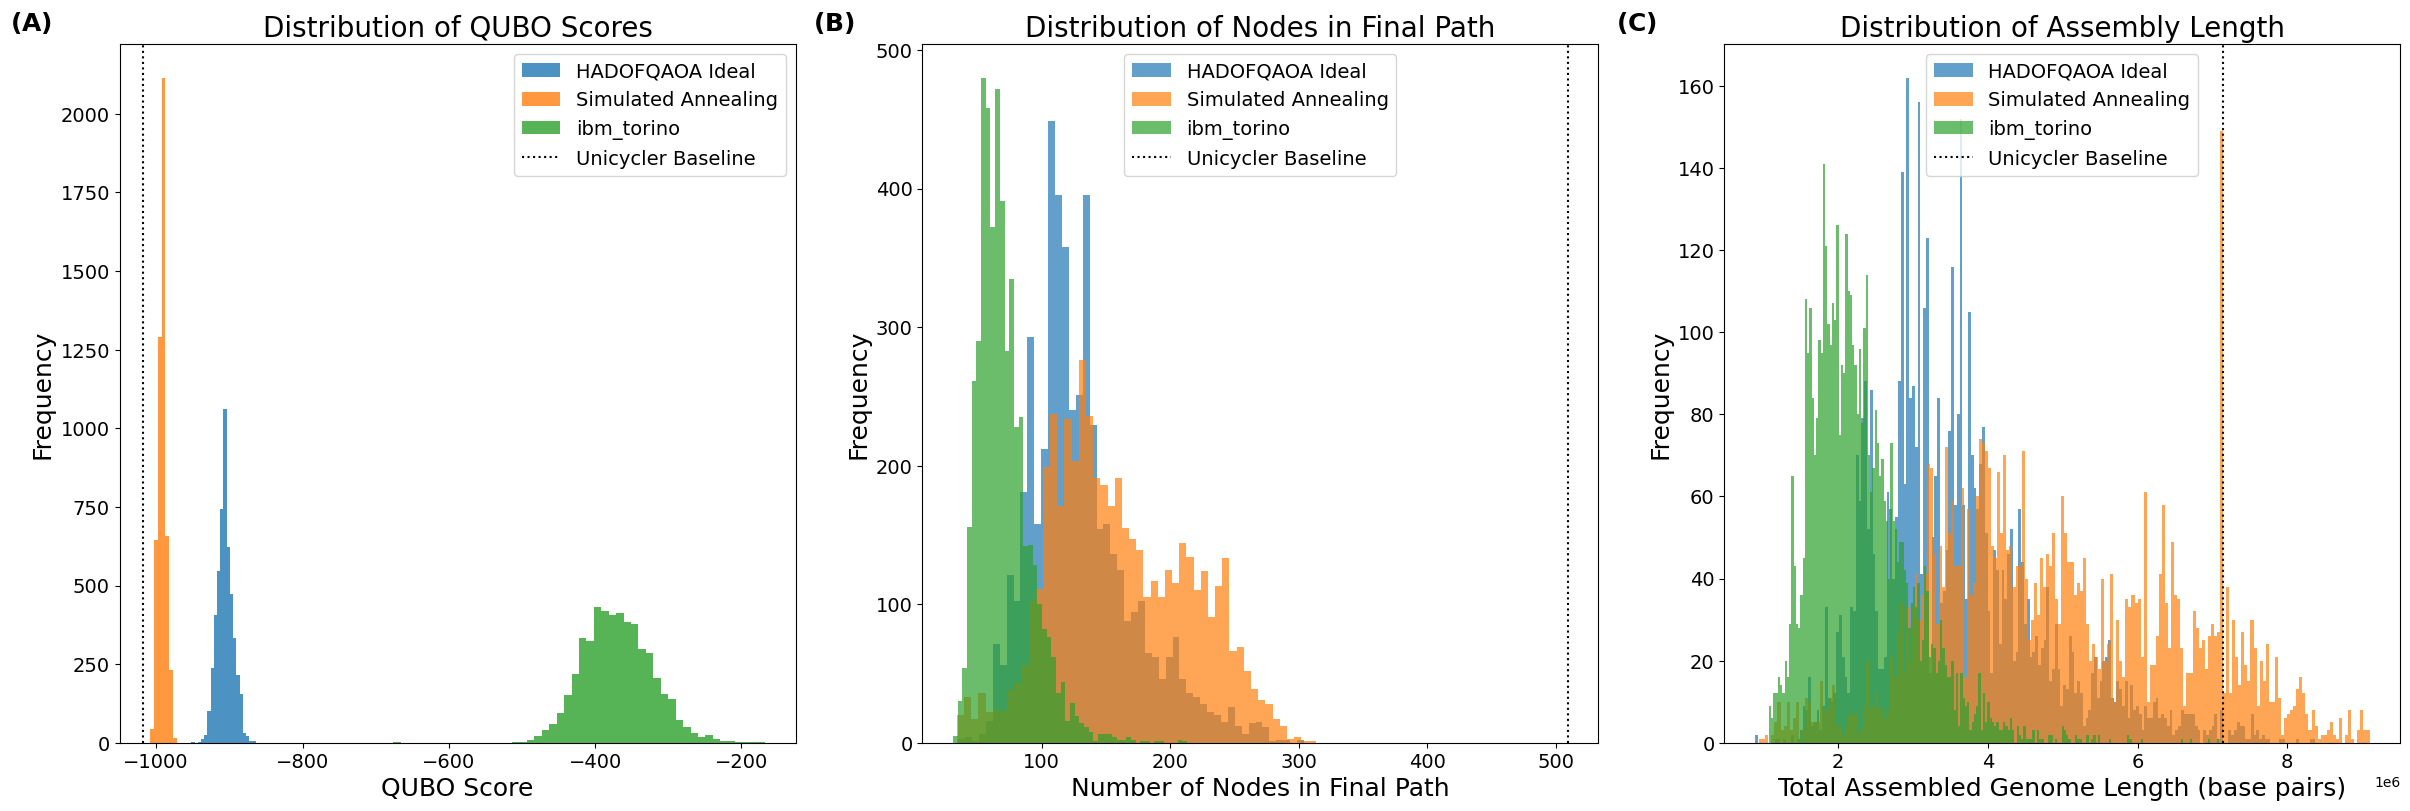

In [25]:
fig1, axes1 = plt.subplots(
    1, 3,
    figsize=(24, 8),
    constrained_layout=True
)

labels1 = ['(A)', '(B)', '(C)']


# --------------------------------------------------
# (A) QUBO Score
# --------------------------------------------------
ax = axes1[0]

ax.hist(
    qubo_score,
    bins=20,
    alpha=0.8,
    label="HADOFQAOA Ideal"
)

ax.hist(
    qubo_score1,
    bins=7,
    alpha=0.8,
    label="Simulated Annealing"
)

ax.hist(
    qubo_score2,
    bins=50,
    alpha=0.8,
    label="ibm_torino"
)
ax.axvline(x=-1018, color='black', linestyle=':', label='Unicycler Baseline')
ax.set_xlabel("QUBO Score", fontsize=18)
ax.set_ylabel("Frequency", fontsize=18)
ax.set_title("Distribution of QUBO Scores", fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.legend(fontsize=14)

# --------------------------------------------------
# (B) Number of Nodes
# --------------------------------------------------
ax = axes1[1]

ax.hist(
    nodes_total,
    bins=50,
    alpha=0.7,
    label="HADOFQAOA Ideal"
)

ax.hist(
    nodes_total1,
    bins=50,
    alpha=0.7,
    label="Simulated Annealing"
)

ax.hist(
    nodes_total2,
    bins=50,
    alpha=0.7,
    label="ibm_torino"
)
ax.axvline(x=509, color='black', linestyle=':', label='Unicycler Baseline')
ax.set_xlabel("Number of Nodes in Final Path", fontsize=18)
ax.set_ylabel("Frequency", fontsize=18)
ax.set_title("Distribution of Nodes in Final Path", fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.legend(fontsize=14)

# --------------------------------------------------
# (C) Total Assembly Length
# --------------------------------------------------
ax = axes1[2]

ax.hist(
    metrics_df["total_length"],
    bins=200,
    alpha=0.7,
    label="HADOFQAOA Ideal"
)

ax.hist(
    metrics_df1["total_length"],
    bins=200,
    alpha=0.7,
    label="Simulated Annealing"
)

ax.hist(
    metrics_df2["total_length"],
    bins=200,
    alpha=0.7,
    label="ibm_torino"
)
ax.axvline(x=7139404, color='black', linestyle=':', label='Unicycler Baseline')
ax.set_xlabel("Total Assembled Genome Length (base pairs)", fontsize=18)
ax.set_ylabel("Frequency", fontsize=18)
ax.set_title("Distribution of Assembly Length", fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.legend(fontsize=14)

# --------------------------------------------------
# Panel labels
# --------------------------------------------------
for i, ax in enumerate(axes1):
    ax.text(
        -0.1, 1.05,
        rf"$\mathbf{{{labels1[i]}}}$",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="right"
    )

plt.show()